# Lab 10 — Image Segmentation and Feature Extraction
**Course:** ARTI404 – Image Processing  
**College of Computer Science and Information Technology**  
**Imam Abdulrahman Bin Faisal University**




## Setup — Import libraries

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import data

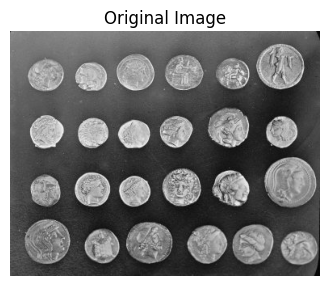

In [2]:
img = data.coins()

plt.figure(figsize=(4,4))
plt.imshow(img, cmap='gray')
plt.title('Original Image')
plt.axis('off')
plt.show()

## Task 1 — Canny Edge Detection

An **edge** is where brightness changes sharply. Canny (1986) finds edges in 5 steps: Gaussian blur → gradients → non-maximum suppression (thin the edges) → double thresholding → hysteresis (keep weak edges only if they connect to strong ones).


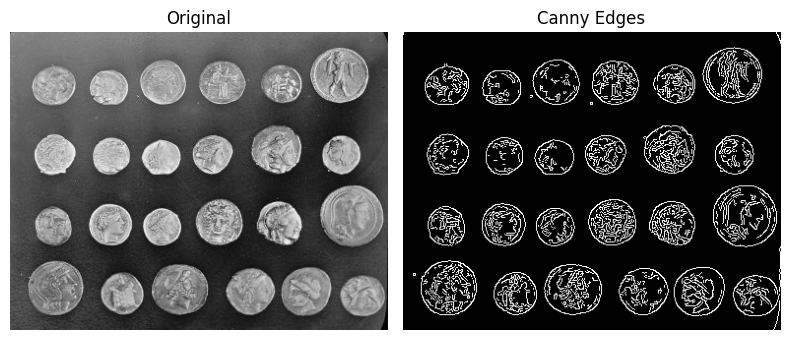

In [3]:
edges = cv2.Canny(img, 100, 200)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title('Canny Edges')
plt.axis('off')

plt.tight_layout()
plt.show()

## Task 2 — Harris Corner Detection

A **corner** is a point where the image changes in *two* different directions — which makes corners highly distinctive (useful for matching, tracking, camera calibration).



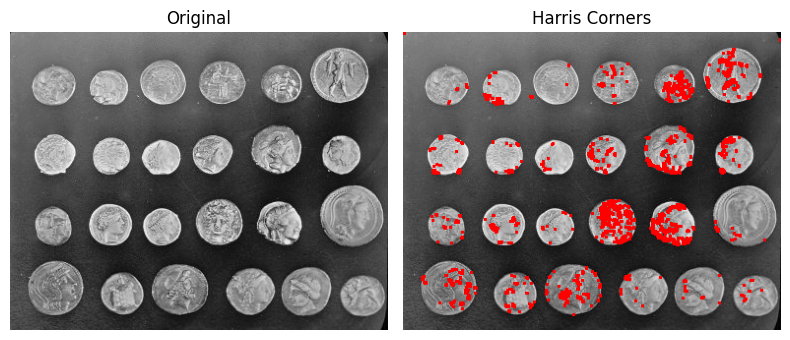

In [4]:
img_float = np.float32(img)
harris = cv2.cornerHarris(img_float, 2, 3, 0.04)

harris_dilated = cv2.dilate(harris, None)

img_harris = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
img_harris[harris_dilated > 0.01 * harris_dilated.max()] = [255, 0, 0]

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(img_harris)
plt.title('Harris Corners')
plt.axis('off')

plt.tight_layout()
plt.show()

## Simple (Global) Binary Thresholding
The most basic segmentation: pick a fixed threshold `T` and turn every pixel above it white, below it black.

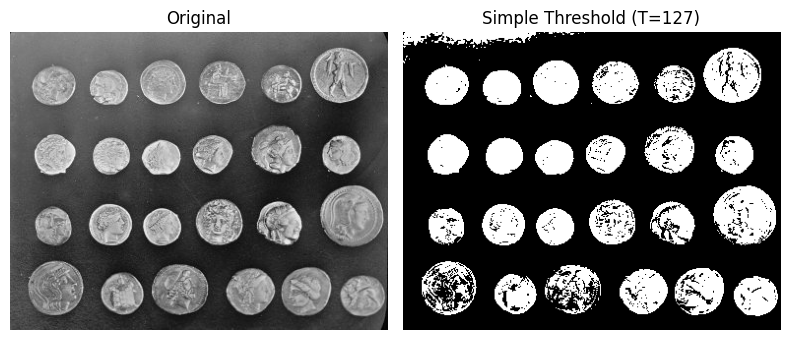

In [5]:
T = 127
_, binary = cv2.threshold(img, T, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(binary, cmap='gray')
plt.title(f'Simple Threshold (T={T})')
plt.axis('off')

plt.tight_layout()
plt.show()

## Q1 — Otsu's Thresholding (Assessment Task)
Otsu picks `T` **automatically** by maximizing the between-class variance — assumes the histogram has two peaks (foreground + background).

show the original image, its histogram, and the thresholded image.

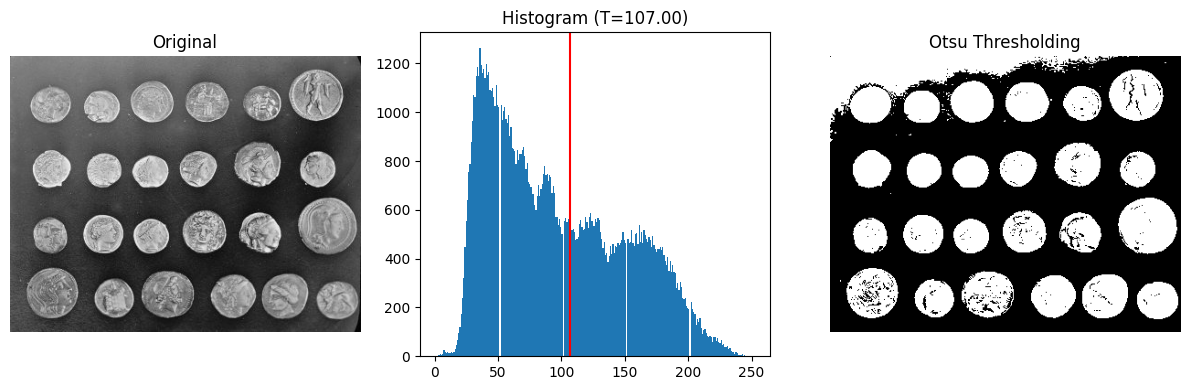

In [6]:
T_otsu, otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.figure(figsize=(12,4))

# Original
plt.subplot(1,3,1)
plt.imshow(img, cmap='gray')
plt.title('Original')
plt.axis('off')

# Histogram
plt.subplot(1,3,2)
plt.hist(img.ravel(), bins=256)
plt.axvline(T_otsu, color='r')
plt.title(f'Histogram (T={T_otsu:.2f})')

# Otsu Result
plt.subplot(1,3,3)
plt.imshow(otsu, cmap='gray')
plt.title('Otsu Thresholding')
plt.axis('off')

plt.tight_layout()
plt.show()

---
## Summary table

| Technique | Category | What it finds | OpenCV function |
|---|---|---|---|
| Canny | Edge detection | Thin connected edges | `cv2.Canny` |
| Sobel | Edge detection | Gradient magnitude (thick) | `cv2.Sobel` |
| Laplacian | Edge detection | Zero-crossings (2nd deriv) | `cv2.Laplacian` |
| Harris | Feature extraction | Corners | `cv2.cornerHarris` |
| Shi-Tomasi | Feature extraction | Corners (improved) | `cv2.goodFeaturesToTrack` |
| Simple threshold | Segmentation | Fixed-`T` binary mask | `cv2.threshold` |
| Otsu | Segmentation | Auto bimodal threshold | `cv2.threshold` + `THRESH_OTSU` |
| Adaptive threshold | Segmentation | Local-`T` binary mask | `cv2.adaptiveThreshold` |

**End of notebook.**